In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

sns.set_theme(style='whitegrid')

df = sns.load_dataset('titanic')
df = df.dropna(subset=['age', 'fare', 'embarked'])

numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
categorical_cols = ['sex', 'class', 'embarked', 'who']

palette = {0: '#d62728', 1: '#2ca02c'}
survival_labels = {0: 'Did not survive', 1: 'Survived'}

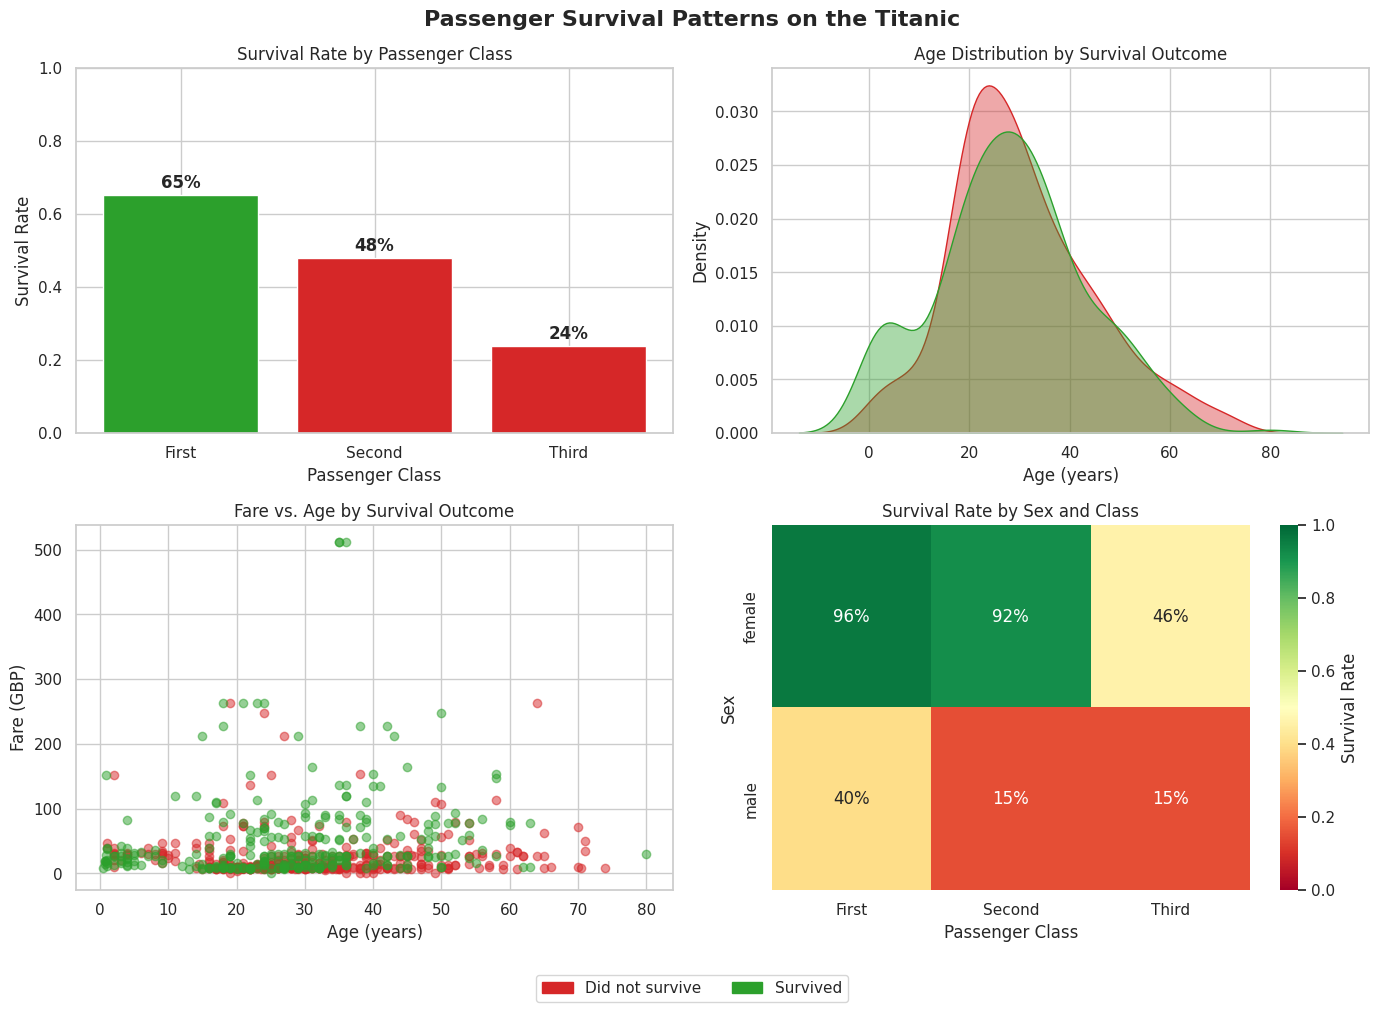

In [2]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Passenger Survival Patterns on the Titanic', fontsize=16, fontweight='bold')

# Panel 1: Survival rate by class
ax = axes[0, 0]
rate_by_class = df.groupby('class')['survived'].mean()
bars = ax.bar(rate_by_class.index.astype(str), rate_by_class.values,
              color=[palette[1] if v >= 0.5 else palette[0] for v in rate_by_class.values])
for bar, val in zip(bars, rate_by_class.values):
    ax.annotate(f'{val:.0%}', xy=(bar.get_x() + bar.get_width() / 2, val),
                xytext=(0, 5), textcoords='offset points', ha='center', fontweight='bold')
ax.set_title('Survival Rate by Passenger Class')
ax.set_xlabel('Passenger Class')
ax.set_ylabel('Survival Rate')
ax.set_ylim(0, 1)

# Panel 2: Age distribution by survival outcome
ax = axes[0, 1]
for outcome, group in df.groupby('survived'):
    sns.kdeplot(group['age'], ax=ax, fill=True, alpha=0.4,
                color=palette[outcome], label=survival_labels[outcome])
ax.set_title('Age Distribution by Survival Outcome')
ax.set_xlabel('Age (years)')
ax.set_ylabel('Density')

# Panel 3: Fare vs. age scatter, coloured by survival
ax = axes[1, 0]
for outcome, group in df.groupby('survived'):
    ax.scatter(group['age'], group['fare'], color=palette[outcome],
               alpha=0.5, label=survival_labels[outcome])
ax.set_title('Fare vs. Age by Survival Outcome')
ax.set_xlabel('Age (years)')
ax.set_ylabel('Fare (GBP)')

# Panel 4: Survival rate heatmap by sex and class
ax = axes[1, 1]
pivot = df.pivot_table(values='survived', index='sex', columns='class', aggfunc='mean')
sns.heatmap(pivot, annot=True, fmt='.0%', cmap='RdYlGn', vmin=0, vmax=1, ax=ax,
            cbar_kws={'label': 'Survival Rate'})
ax.set_title('Survival Rate by Sex and Class')
ax.set_xlabel('Passenger Class')
ax.set_ylabel('Sex')

# Shared legend for the figure
handles = [mpatches.Patch(color=palette[k], label=v) for k, v in survival_labels.items()]
fig.legend(handles=handles, loc='lower center', ncol=2, bbox_to_anchor=(0.5, -0.02))

plt.tight_layout(rect=[0, 0.03, 1, 1])
plt.savefig('titanic_survival_dashboard.png', dpi=300, bbox_inches='tight')
plt.show()

In [3]:
best_class = rate_by_class.idxmax()
worst_class = rate_by_class.idxmin()
gap = rate_by_class.max() - rate_by_class.min()

age_means = df.groupby('survived')['age'].mean()
younger_group = 'survivors' if age_means[1] < age_means[0] else 'non-survivors'

fare_corr = df['fare'].corr(df['survived'])

print(
    f"1. Survival chances were strongly tied to passenger class: {best_class} class passengers "
    f"survived at a rate of {rate_by_class[best_class]:.0%}, compared with only "
    f"{rate_by_class[worst_class]:.0%} for {worst_class} class, a gap of {gap:.0%}.\n"
    f"2. {younger_group.capitalize()} were on average younger ({age_means.idxmin()}: "
    f"{age_means.min():.1f} years vs. {age_means.idxmax()}: {age_means.max():.1f} years), "
    f"suggesting age played a role alongside class.\n"
    f"3. Fare and survival show a positive relationship (r = {fare_corr:.2f}), and the heatmap confirms "
    f"that women in higher classes had by far the best odds of survival."
)

1. Survival chances were strongly tied to passenger class: First class passengers survived at a rate of 65%, compared with only 24% for Third class, a gap of 41%.
2. Survivors were on average younger (1: 28.2 years vs. 0: 30.6 years), suggesting age played a role alongside class.
3. Fare and survival show a positive relationship (r = 0.27), and the heatmap confirms that women in higher classes had by far the best odds of survival.
